### Import libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load and study the dataset

In [2]:
df = pd.read_csv("airports.csv")
# source: https://ourairports.com/data/

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84897 entries, 0 to 84896
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 84897 non-null  int64  
 1   ident              84897 non-null  object 
 2   type               84897 non-null  object 
 3   name               84897 non-null  object 
 4   latitude_deg       84897 non-null  float64
 5   longitude_deg      84897 non-null  float64
 6   elevation_ft       70193 non-null  float64
 7   continent          45416 non-null  object 
 8   iso_country        84605 non-null  object 
 9   iso_region         84897 non-null  object 
 10  municipality       80138 non-null  object 
 11  scheduled_service  84897 non-null  object 
 12  icao_code          9812 non-null   object 
 13  iata_code          9063 non-null   object 
 14  gps_code           43989 non-null  object 
 15  local_code         35980 non-null  object 
 16  home_link          466

In [4]:
df.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


In [5]:
df.columns

Index(['id', 'ident', 'type', 'name', 'latitude_deg', 'longitude_deg',
       'elevation_ft', 'continent', 'iso_country', 'iso_region',
       'municipality', 'scheduled_service', 'icao_code', 'iata_code',
       'gps_code', 'local_code', 'home_link', 'wikipedia_link', 'keywords'],
      dtype='object')

In [6]:
df.isnull().sum()

id                       0
ident                    0
type                     0
name                     0
latitude_deg             0
longitude_deg            0
elevation_ft         14704
continent            39481
iso_country            292
iso_region               0
municipality          4759
scheduled_service        0
icao_code            75085
iata_code            75834
gps_code             40908
local_code           48917
home_link            80236
wikipedia_link       68227
keywords             63838
dtype: int64

<Axes: >

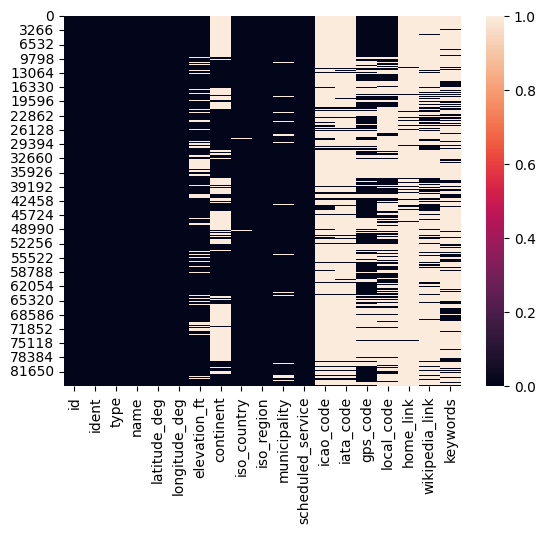

In [7]:
sns.heatmap(df.isnull())

### Drop unnecessary columns

In [8]:
cols_toDrop = ['elevation_ft', 'continent', 'municipality', 'scheduled_service', 'icao_code',
       'gps_code', 'local_code', 'home_link', 'wikipedia_link', 'keywords']

In [9]:
df_lessCols = df.copy()
df_lessCols.drop(labels = cols_toDrop, axis = 1, inplace = True)

### See null values

In [10]:
df_lessCols.isnull().sum()

id                   0
ident                0
type                 0
name                 0
latitude_deg         0
longitude_deg        0
iso_country        292
iso_region           0
iata_code        75834
dtype: int64

### Remove all airport types except for medium and large airports
Because most of them do not have iata code

In [11]:
df_lessCols.groupby(['type'])['id'].count()

type
balloonport          61
closed            13012
heliport          22726
large_airport      1194
medium_airport     4067
seaplane_base      1255
small_airport     42582
Name: id, dtype: int64

In [12]:
# Remove all the rows except for Large and Medium airports
rows_toExclude = ['heliport', 'balloonport', 'closed', 'seaplane_base', 'small_airport']
df_cleaned = df_lessCols[~df_lessCols['type'].isin(rows_toExclude)]
df_cleaned['type'].unique()

array(['medium_airport', 'large_airport'], dtype=object)

### Remove all rows without IATA code
Since airports without IATA codes are not used commercially, I'm removing all the airports with no IATA code

In [13]:
df_cleaned.isnull().sum()

id                 0
ident              0
type               0
name               0
latitude_deg       0
longitude_deg      0
iso_country       13
iso_region         0
iata_code        707
dtype: int64

In [14]:
# Take all the rows with IATA codes
df_cleaned = df_cleaned[df_cleaned['iata_code'].notnull()].copy()

In [15]:
df_cleaned.isnull().sum()

id                0
ident             0
type              0
name              0
latitude_deg      0
longitude_deg     0
iso_country      12
iso_region        0
iata_code         0
dtype: int64

<Axes: >

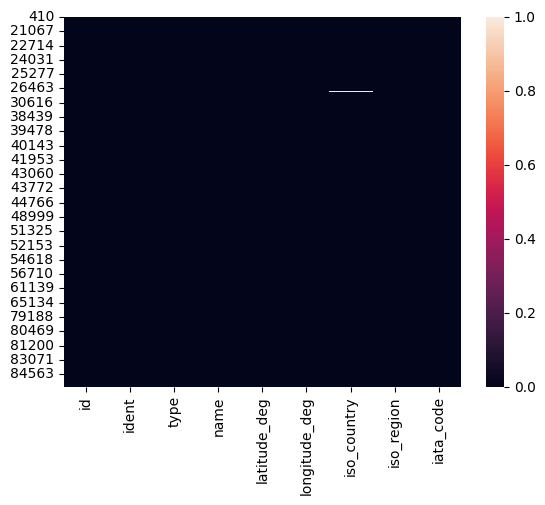

In [16]:
sns.heatmap(df_cleaned.isnull())

In [17]:
df_cleaned[df_cleaned['iso_country'].isnull()]

,id,ident,type,name,latitude_deg,longitude_deg,iso_country,iso_region,iata_code
28002,3024,FYAR,medium_airport,Arandis Airport,-22.461875,14.979322,NaN,NA-ER,ADI
28020,3026,FYGF,medium_airport,Grootfontein Airport,-19.602200,18.122700,NaN,NA-OD,GFY
28037,3027,FYKM,medium_airport,Katima Mulilo Airport,-17.634258,24.176688,NaN,NA-CA,MPA
28040,3028,FYKT,medium_airport,Keetmanshoop Airport,-26.539801,18.111401,NaN,NA-KA,KMP
28048,3029,FYLZ,medium_airport,Luderitz Airport,-26.687401,15.242900,NaN,NA-KA,LUD
28061,3031,FYOA,medium_airport,Ondangwa Airport,-17.878201,15.952600,NaN,NA-ON,OND
28063,3032,FYOG,medium_airport,Oranjemund Airport,-28.584700,16.446699,NaN,NA-KA,OMD
28076,3035,FYRU,medium_airport,Rundu Airport,-17.956499,19.719400,NaN,NA-KE,NDU
28089,3036,FYTM,medium_airport,Tsumeb Airport,-19.262079,17.732509,NaN,NA-OT,TSB
28092,3037,FYWB,large_airport,Walvis Bay International Airport,-22.979332,14.647102,NaN,NA-ER,WVB


In [18]:
# Missing country code "NA", which is Nambia

In [19]:
df_final = df_cleaned.fillna("NA")

In [20]:
df_final.isnull().sum()

id               0
ident            0
type             0
name             0
latitude_deg     0
longitude_deg    0
iso_country      0
iso_region       0
iata_code        0
dtype: int64

In [26]:
df_final.sort_values(by='id', inplace=True)
df_final = df_final.reset_index(drop=True)

In [27]:
df_final.head()

,id,ident,type,name,latitude_deg,longitude_deg,iso_country,iso_region,iata_code
0,3,AGGH,large_airport,Honiara International Airport,-9.428000,160.054993,SB,SB-GU,HIR
1,4,AGGM,medium_airport,Munda Airport,-8.327970,157.263000,SB,SB-WE,MUA
2,8,ANYN,medium_airport,Nauru International Airport,-0.547893,166.919525,NR,NR-14,INU
3,53,AYBK,medium_airport,Buka Airport,-5.422299,154.672698,PG,PG-NSB,BUA
4,54,AYCH,medium_airport,Chimbu Airport,-6.024290,144.970993,PG,PG-CPK,CMU
